The script is used to analysis the calibration result, comparing the model output and observation for the period 2000-2020, for Sabinebreen


# 1. import necessary library

In [ ]:
import os
import sys
sys.path.insert(0, sys.path.append(os.getcwd() + '/../'))
sys.path.insert(0, sys.path.append(os.getcwd() + '/../PyGEM-scripts'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
import ast
import csv  # Import the standard csv module
from scipy.stats import linregress
import argparse
import pickle
import gzip
from collections import OrderedDict
# Load the local libraries

#import pygem_input as pygem_prms

#import Visualization_timeseries as Vis_ts
import statistic_tool as stats_t
# debug lib
import pdb
from matplotlib.lines import Line2D  # Import Line2D for custom legend
import matplotlib.lines as mlines  # Import for custom legend handling
import json
import Graphic_RT
from Graphic_RT import plot_modeloutput_section_New
from Graphic_RT import surf_to_nan

# 2. set the path

In [2]:
# Function to extract regional id and rgiid float from rgiid string
def extract_regional_rgiid_float(rgiid = None,index_full = False):
    """
    Extract reg_id and rgi_float from RGI ID.
    
    Args:
        rgiid (str): RGI ID string, e.g., 'RGI60-07.00120' or 'RGI60-11.12500'
    
    Returns:
        tuple: (reg_id, rgi_float) where:
            - reg_id is the region ID as string, e.g., '07', '11'
            - rgi_float is the float value as string, e.g., '7.00120', '11.12500'
    """
    # Regional_full name
    reg_id_R1_full = rgiid[:-6]
    reg_id_R2_full = rgiid[:-3]
    # Remove the 'RGI60-' prefix
    suffix = rgiid.replace('RGI60-', '')
    
    # Split by dot to separate the integer and decimal parts
    parts = suffix.split('.')
    
    # Extract reg_id (the part before decimal, keeping leading zeros)
    reg_id = parts[0]
    
    # Construct rgi_float by removing leading zero from integer part if needed
    if reg_id.startswith('0') and len(reg_id) > 1:
        # Remove leading zero for the float representation
        rgi_float = f"{int(reg_id)}.{parts[1]}"
    else:
        # No leading zero to remove
        rgi_float = f"{reg_id}.{parts[1]}"

    # return the full name or just short name
    if index_full:
        return reg_id, rgi_float,reg_id_R1_full,reg_id_R2_full
    else:
        return reg_id, rgi_float

In [ ]:
# Path
output_path= sys.path.append(os.getcwd() + '/Calibration/')
modeloutput = output_path + 'modeloutput/'
RGIID = 'RGI60-07.00036'
reg, glacier_str,reg_R1_full,reg_R2_full = extract_regional_rgiid_float(rgiid = RGIID,index_full = True)
modeloutput_reg = os.path.join(modeloutput, f"{str(reg).zfill(2)}/")
modeloutput_glac = os.path.join(modeloutput_reg, glacier_str)
output_folder_weights = os.path.join(modeloutput_glac,'Poster', 'Weighted')
output_filename_weighted = f'calibration_weighted_output_{RGIID}_poster.json' # dataset with weighted output
output_fp_weighted = os.path.join(output_folder_weights, output_filename_weighted)
# gdir file path
gdir_fp = sys.path.append(os.getcwd() + '/../Input/oggm_gdirs/')
gdir_fp_glac = os.path.join(gdir_fp,'per_glacier',reg_R1_full,reg_R2_full,RGIID)
# observation path
observation_path = sys.path.append(os.getcwd() + '/../Input/Calibration_dataset/RGI_fit_Obs_fa_dLdt_MB/')

# 3. add the velocity from both modeled ensembles and remote sensing ITS_LIVE

In [4]:
# load the velocity from model and ITS_LIVE (Detailed process in Sabinebreen_Terminus_velocity_comparision)
# Read the model ensemble
Vel_model_annual_ensemble_fn = f"Velocity_model_ensemble_{RGIID}.npy"
Vel_model_annual_ensemble_fp = os.path.join(output_folder_weights, Vel_model_annual_ensemble_fn)
Vel_model_annual_ensemble = np.load(Vel_model_annual_ensemble_fp)
# load the weighted average
# read the weighted average value
with open(output_fp_weighted, 'r') as f:
    weighted_data = json.load(f)
# First, let's see what's in the JSON file
print("JSON structure keys:", weighted_data.keys())
Vel_model_weighted = weighted_data['velocity_at_calvingfront_model_array_annual_weighted_myr']

JSON structure keys: dict_keys(['calving_flux_Gta_average_model_weighted', 'calving_thickness_model_weighted_m', 'massbalclim_model_weighted_mwea', 'massbaltotal_model_weighted_mwea', 'FA_mwea_average_model_weighted', 'lengthchange_dLdt_model_annual_weighted_myr', 'lengthchange_m_TMS_model_annual_weighted', 'calving_flux_Gta_TMS_model_annual_weighted', 'massbalclim_TMS_model_annual_weighted_mwea', 'massbaltotal_TMS_model_annual_weighted_mwea', 'FA_mwea_TMS_model_annual_weighted', 'velocity_at_calvingfront_model_array_annual_weighted_myr', 'thickness_at_calvingfront_model_array_annual_weighted_m', 'width_at_calvingfront_model_array_annual_weighted_m', 'volume_bsl_model_array_annual_weighted_m3', 'volume_bwl_model_array_annual_weighted_m3'])


In [5]:
# Read the its_live
Itslive_df_fn = f"extracted_its_live_velocity_annual_coordinate_{RGIID}.csv"
Itslive_df_fp = os.path.join(output_folder_weights, Itslive_df_fn)  # specify your output directory
Itslive_df = pd.read_csv(Itslive_df_fp)

# 4. Get the glacier topography info

In [6]:
gdir_flowline_fp = os.path.join(gdir_fp_glac,'model_flowlines.pkl')
_open = gzip.open
with _open(gdir_flowline_fp, 'rb') as f:
    nfls = pickle.load(f)
bu_fl = nfls[-1]

In [11]:
# Function to plot the glacier profile from flowline model with the area histogram
def plot_glacier_topo(fls=None, ax=None, fig_fontsize=12):
    """Plots the result of the model output along the flowline.

    Parameters
    ----------
    fls: list
        List of FlowlineModel objects
    ax: matplotlib.axes.Axes, optional
        Axes to plot on. If None, a new figure and axes are created.
    fig_fontsize: int, optional
        Font size for the figure.
    """


    if ax is None:
        fig = plt.figure(figsize=(12, 6))
        ax = fig.add_axes([0.07, 0.08, 0.7, 0.84])
    else:
        fig = plt.gcf()

    # Compute area histo
    area = np.array([])
    height = np.array([])
    bed = np.array([])
    for cls in fls:
        a = cls.widths_m * cls.dx_meter * 1e-6
        a = np.where(cls.thick > 0, a, 0)
        area = np.concatenate((area, a))
        height = np.concatenate((height, cls.surface_h))
        bed = np.concatenate((bed, cls.bed_h))
    ylim = [bed.min(), height.max()]

    # Plot histo
    posax = ax.get_position()
    posax = [posax.x0 + 2 * posax.width / 3.0,
             posax.y0,  posax.width / 3.0,
             posax.height]
    axh = fig.add_axes(posax, frameon=False)

    axh.hist(height, orientation='horizontal', range=ylim, bins=20,
             alpha=0.3, weights=area)
    axh.invert_xaxis()
    axh.xaxis.tick_top()
    axh.set_xlabel('Area (km$^2$)',fontsize = fig_fontsize)
    axh.xaxis.set_label_position('top')
    axh.set_ylim(ylim)
    axh.yaxis.set_ticks_position('right')
    axh.set_yticks([])
    axh.axhline(y=ylim[1], color='black', alpha=1)  # qick n dirty trick

    # plot Centerlines
    cls = fls[-1]
    x = np.arange(cls.nx) * cls.dx * cls.map_dx/1000

    # Plot the bed
    ax.plot(x, cls.bed_h, color='k', linewidth=2.5, label='Bed')

    # Where trapezoid change color
    # if hasattr(cls, '_do_trapeze') and cls._do_trapeze:
    #     bed_t = cls.bed_h * np.NaN
    #     pt = cls.is_trapezoid & (~cls.is_rectangular)
    #     bed_t[pt] = cls.bed_h[pt]
    #     ax.plot(x, bed_t, color='rebeccapurple', linewidth=2.5,
    #             label='Bed (Trap.)')
    #     bed_t = cls.bed_h * np.NaN
    #     bed_t[cls.is_rectangular] = cls.bed_h[cls.is_rectangular]
    #     ax.plot(x, bed_t, color='crimson', linewidth=2.5, label='Bed (Rect.)')

    # Plot glacier
    surfh = Graphic_RT.surf_to_nan(cls.surface_h, cls.thick)
    ax.plot(x, surfh, color='#003399', linewidth=2, label='Glacier')

    # Plot tributaries
    for i, l in zip(cls.inflow_indices, cls.inflows):
        if l.thick[-1] > 0:
            ax.plot(x[i], cls.surface_h[i], 's', markerfacecolor='#993399',
                    markeredgecolor='k',
                    label='Tributary (active)')
        else:
            ax.plot(x[i], cls.surface_h[i], 's', markerfacecolor='w',
                    markeredgecolor='k',
                    label='Tributary (inactive)')
    if getattr(fls, 'do_calving', False):
        ax.hlines(fls.water_level, x[0], x[-1], linestyles=':', color='C0')

    ax.set_ylim(ylim)
    ax.set_xlim(left =0)
    # add the horizontal line, y=0
    ax.axhline(y=0,linestyle='--',color='k',linewidth=0.5)

    ax.spines['top'].set_color('none')
    ax.xaxis.set_ticks_position('bottom')
    ax.set_xlabel('Distance along flowline (km)',fontsize = fig_fontsize)
    ax.set_ylabel('Elevation (m a.s.l.)',fontsize = fig_fontsize)


    # Legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = OrderedDict(zip(labels, handles))
    ax.legend(list(by_label.values()), list(by_label.keys()),
              bbox_to_anchor=(0,0),
              loc = 'lower left',
              fontsize = fig_fontsize-1,
              frameon=False)
    # plt.show()
    # plt.close()

# 5.  Plot dLdt , velocity modeled vs obs (2*2)

In [ ]:
# Function to plot length change (annual,cumulative) for both SERMeQ and flowline model profile, and glacier topography with velocity at the terminus
def plot_dLdt_topo_Vel_model_vs_obs_2x2(
    output_path= None,
    output_fn='calibration_model_Annual_output',
    rgiid=None,
    N_iteration='Poster',
    observation_path= None,
    # Additional parameters for velocity and topography
    fls=None,
    Vel_model_annual_ensemble=None,
    Vel_model_weighted=None,
    Itslive_df=None,
    start_year=2000,
    calibration_period=(2000, 2009),
    save_path=None,
    save_name=None,
    topo_kwargs=None,
    fig_fontsize=12,
    figuresize=(14, 16),
    fig_dpi=600,

):
    """
    Plot glacier length change (annual and cumulative) from both SERMeQ and flowline model profile,
    along with glacier topography and velocity at the terminus in a 3x2 subplot layout.
    Parameters:
    - output_path (str): Path to model output data.
    - output_fn (str): File name of the model output data.
    - rgiid (str): Glacier ID.
    - N_iteration (str): Iteration number for model output.
    - observation_path (str): Path to observation data.
    - fls: list of FlowlineModel objects for glacier topography.
    - Vel_model_annual_ensemble: np.ndarray, ensemble of modeled annual velocities at the terminus.
    - Vel_model_weighted: np.ndarray, weighted mean of modeled annual velocities at the terminus.
    - Itslive_df: pd.DataFrame, ITS_LIVE observations with
        columns 'Year', 'v', and 'v_error'.
    - start_year (int): Starting year for the time series.
    - calibration_period (tuple): (start, end) years for calibration period shading.
    - save_path (str): Path to save the figure.
    - save_name (str): Name of the saved figure file.
    - topo_kwargs (dict): Additional keyword arguments for topography plot.
    - fig_fontsize (int): Font size for labels and titles.
    - figuresize (tuple): Figure size (width, height) in inches.
    - fig_dpi (int): Resolution of the saved figure.
    Returns:
    - None
    """
    
    if not rgiid:
        print("Error: RGI ID must be provided.")
        return

    # Generate regional ID and RGIID float
    reg_id, rgiid_float = extract_regional_rgiid_float(rgiid=rgiid)

    # Load model output for length change data
    output_filename = f"modeloutput/{reg_id}/{rgiid_float}/Annual/{output_fn}_{rgiid}_{N_iteration}.json"
    output_fp_annual = os.path.join(output_path, output_filename)

    try:
        with open(output_fp_annual, 'r', encoding='utf-8') as f:
            output_data_annual = json.load(f)
    except Exception as e:
        print(f"Error loading JSON file: {output_fp_annual} - {e}")
        return

    # Load model data for length change
    lengthchange_dLdt_model_array_annual = np.array(output_data_annual['lengthchange_dLdt_model_array_annual_myr'])
    lengthchange_m_TMS_model_array_annual = np.array(output_data_annual['lengthchange_m_TMS_model_array_annual'])

    # Load parameter weights
    output_folder_post_params_unique = os.path.join(output_path, 'parameter', reg_id, rgiid_float, 'Poster', 'Unique')
    output_filename_params_unique_Info = f'calibration_poster_Params_unique_{rgiid}_Info.json'
    output_fp_params_unique_Info = os.path.join(output_folder_post_params_unique, output_filename_params_unique_Info)

    try:
        with open(output_fp_params_unique_Info, 'r') as f:
            parms_UniqInfo_dict = json.load(f)
        unique_counts = parms_UniqInfo_dict['unique_counts']
        weights_unique = unique_counts / np.sum(unique_counts)
    except Exception as e:
        print(f"Error loading parameter info: {e}")
        return

    # Repeat model output based on unique counts and compute weighted averages
    lengthchange_dLdt_model_array_annual_post = np.repeat(lengthchange_dLdt_model_array_annual, unique_counts, axis=1)
    lengthchange_m_TMS_model_array_annual_post = np.repeat(lengthchange_m_TMS_model_array_annual, unique_counts, axis=1)
    
    lengthchange_dLdt_weighted = np.average(lengthchange_dLdt_model_array_annual, axis=1, weights=weights_unique)
    lengthchange_m_TMS_weighted = np.average(lengthchange_m_TMS_model_array_annual, axis=1, weights=weights_unique)

    # Load observation data
    observation_annual_fn = f'lengthchange_annual_rgi_region01_{int(reg_id)}_20002020.csv'
    observation_annual_fp = os.path.join(observation_path, observation_annual_fn)
    
    try:
        observation_data = pd.read_csv(observation_annual_fp)
        mask = observation_data.RGIId == rgiid
        
        if not mask.any():
            print(f"Error: No observation data found for RGI ID {rgiid}")
            return
            
        obs_annual = np.array(observation_data.loc[mask, 'dLdt_m_per_yr'].apply(ast.literal_eval).tolist(), dtype=float)
        obs_annual_unc = np.array(observation_data.loc[mask, 'dLdt_m_per_yr_unc'].apply(ast.literal_eval).tolist(), dtype=float)
    except Exception as e:
        print(f"Error loading observation data: {e}")
        return

    # Compute cumulative sums
    cum_dLdt_model = np.cumsum(lengthchange_dLdt_model_array_annual_post, axis=0)
    cum_TMS_model = np.cumsum(lengthchange_m_TMS_model_array_annual_post, axis=0)
    cum_obs = np.cumsum(obs_annual)
    cum_obs_unc = np.sqrt(np.cumsum(obs_annual_unc**2))
    cum_dLdt_weighted = np.cumsum(lengthchange_dLdt_weighted, axis=0)
    cum_TMS_weighted = np.cumsum(lengthchange_m_TMS_weighted, axis=0)

    # Define years
    n_years_vel = cum_dLdt_model.shape[0]
    X_Years = np.arange(start_year, start_year + n_years_vel)

    # Create figure with nested GridSpec for precise control
    fig = plt.figure(figsize=figuresize, dpi=fig_dpi)
    
    # Create main GridSpec with 2 rows: top (rows 1-2) and bottom (row 3)
    # This allows us to control the space between row 2 and 3 specifically
    main_gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.2)  # hspace controls space between row2 and row3
    
    # Top GridSpec for rows 1 and 2 (4 subplots)
    top_gs = main_gs[0].subgridspec(1, 2, wspace=0.165)
    
    # Bottom GridSpec for row 3 (2 subplots)
    bottom_gs = main_gs[1].subgridspec(1, 2, wspace=0.165)
    
    # =========================================================================
    # ROW 1: LENGTH CHANGE RATE PLOTS
    # =========================================================================
    
    # Subplot 1: SERMeQ Rate of change
    ax1 = fig.add_subplot(top_gs[0, 0])
    ax1.axvspan(calibration_period[0], calibration_period[1], alpha=0.05, color='green', label='Calibration')
    
    ax1.plot(X_Years, lengthchange_dLdt_model_array_annual_post, color='grey', alpha=0.5)
    ax1.plot(X_Years, lengthchange_dLdt_weighted, color='black', marker='*', markersize=4, 
            linewidth=1, alpha=1)
    ax1.errorbar(X_Years, obs_annual.squeeze(), yerr=obs_annual_unc.squeeze(), fmt='x',
                label='Observed', ecolor='#056eee', elinewidth=2, capsize=4, 
                mec='#056eee', mfc='#056eee', alpha=1)
    ax1.axhline(y=0,linestyle='--',color ='k',linewidth = 0.5)
    ax1.set_ylabel("Length change rate (m a⁻¹)", fontsize=fig_fontsize)
    #ax1.text(0.02, 0.05, "SERMeQ", transform=ax1.transAxes, fontsize=fig_fontsize-1, color='black')
    ax1.set_xlim(start_year-0.2, start_year + n_years_vel-0.8)

    
    # Subplot 3: SERMeQ Cumulative change
    ax2 = fig.add_subplot(top_gs[0, 1])
    ax2.axvspan(calibration_period[0], calibration_period[1], alpha=0.05, color='green', label='Calibration')
    
    ax2.plot(X_Years, cum_dLdt_model, color='grey', alpha=0.5)
    ax2.plot(X_Years, cum_dLdt_weighted, color='black', marker='*', markersize=4, 
            linewidth=1, alpha=1)
    ax2.plot(X_Years, cum_obs, color='#056eee', label='Observed')
    ax2.fill_between(X_Years, 
                    cum_obs - cum_obs_unc,
                    cum_obs + cum_obs_unc, 
                    color='#056eee', alpha=0.3)
    ax2.axhline(y=0,linestyle='--',color ='k',linewidth = 0.5)
    ax2.set_xlim(start_year-0.2, start_year + n_years_vel-0.8)
    ax2.set_ylabel("Cumulative length Change (m)", fontsize=fig_fontsize)
    #ax2.text(0.02, 0.05, "SERMeQ", transform=ax2.transAxes, fontsize=fig_fontsize-1, color='black')


    
    # =========================================================================
    # ROW 2: TOPOGRAPHY AND VELOCITY
    # =========================================================================
    
    # Subplot 3: Velocity
    ax3 = fig.add_subplot(bottom_gs[0, 0])
    if Vel_model_annual_ensemble is not None and Itslive_df is not None:
        # Plot velocity data
        n_years_vel = Vel_model_annual_ensemble.shape[0]
        X_Years_vel = np.arange(start_year, start_year + n_years_vel)
        
        ax3.plot(X_Years_vel, Vel_model_annual_ensemble, color='grey', alpha=0.5, linewidth=1)
        ax3.plot(X_Years_vel, Vel_model_weighted, color='black', marker='*', markersize=6, 
                linewidth=1.5, alpha=1)
        ax3.errorbar(Itslive_df['Year'], Itslive_df['v'], yerr=Itslive_df['v_error'],
                    color='#056eee', fmt='x', markersize=6, elinewidth=1.5, capsize=4, alpha=1)
        ax3.axvspan(calibration_period[0], calibration_period[1], alpha=0.05, color='green')
        
        # Velocity styling
        ax3.set_ylim(bottom=0)
        ax3.set_xlim(start_year-0.2, start_year + n_years_vel-0.8)
        ax3.set_xlabel('Year', fontsize=fig_fontsize)
        ax3.set_ylabel('Velocity at terminus (m a$^{-1}$)', fontsize=fig_fontsize)
        ax3.set_xticks(X_Years_vel)
        ax3.set_xticklabels([str(year) if year % 2 == 0 else "" for year in X_Years_vel])
        ax3.tick_params(axis='both', which='major', labelsize=10)
        
        # Velocity legend
        vel_legend_handles = [
            mlines.Line2D([], [], color='grey', alpha=0.8, linewidth=2, label='Ensemble members'),
            mlines.Line2D([], [], color='black', marker='*', markersize=6, 
                         linewidth=1.5, label='Weighted mean'),
            mlines.Line2D([], [], color='#056eee', marker='x', markersize=6,
                         linewidth=1, label='ITS_LIVE')
        ]
        ax3.legend(handles=vel_legend_handles, loc='best', fontsize=fig_fontsize-1, frameon=False)
    else:
        ax3.text(0.5, 0.5, "Velocity data not available", 
                transform=ax4.transAxes, ha='center', va='center', fontsize=fig_fontsize)
        ax3.set_xlabel('Year', fontsize=fig_fontsize)

    # Subplot 4: Topography
    ax4 = fig.add_subplot(bottom_gs[0, 1])
    if fls is not None:
        # Use the exact same topography plotting as in the custom function
    
        topo_kwargs_combined = {**(topo_kwargs or {})}
        
        # Call the same plotting function with same parameters
        plot_glacier_topo(fls=fls, ax=ax4, fig_fontsize=fig_fontsize, **topo_kwargs_combined)
        
        # Ensure the same styling as the custom function
        ax4.set_xlabel("Distance along flowline (km)", fontsize=fig_fontsize)
        ax4.tick_params(axis='both', which='major', labelsize=10)
    else:
        ax4.text(0.5, 0.5, "Topography data not available", 
                transform=ax3.transAxes, ha='center', va='center', fontsize=fig_fontsize)
        ax4.set_xlabel("Distance along flowline (km)", fontsize=fig_fontsize)
    # =========================================================================
    # STYLING AND LABELS
    # =========================================================================
    
    # Set x-ticks for all time series plots
    for ax in [ax1, ax2, ax3]:
        ax.set_xticks(X_Years)
        ax.set_xticklabels([str(year) if year % 2 == 0 else "" for year in X_Years])
        ax.tick_params(axis='both', which='major', labelsize=10)
    

    ax1.set_xlabel('Year', fontsize=fig_fontsize)
    ax2.set_xlabel('Year', fontsize=fig_fontsize)
    # Add legend to first length change subplot
    len_legend_handles = [
        mlines.Line2D([], [], color='grey', alpha=0.8, linewidth=2, label='Ensemble members'),
        mlines.Line2D([], [], color='black', marker='*', markersize=6, linewidth=1, label='Weighted mean'),
        mlines.Line2D([], [], color='#056eee', marker='x', markersize=6, linewidth=1, label='Observed')
    ]
    ax1.legend(handles=len_legend_handles, loc='best', fontsize=fig_fontsize-1, frameon=False)
    
    # Add subplot labels
    for i, ax in enumerate([ax1, ax2, ax3, ax4]):
        label = chr(97 + i)  # a, b, c, d, e, f
        ax.text(-0.08, 0.95, label, transform=ax.transAxes, 
                fontsize=20, fontweight='normal', va='bottom', ha='right')
    
    # Save figure
    if save_path is None:
        save_path = os.path.join(output_path, 'figures', reg_id, rgiid_float)
    
    if save_name is None:
        save_name = f'Glacier_dLdt_model_vs_obs_topo_Velocity_model_vs_obs_4subplots_{rgiid}_Updated.png'

    os.makedirs(save_path, exist_ok=True)
    save_file = os.path.join(save_path, save_name)
    plt.savefig(save_file, bbox_inches='tight', dpi=500)
    print(f"4-subplot figure saved to: {save_file}")
    
    return fig, [ax1, ax2, ax3, ax4]

4-subplot figure saved to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/figures/07/7.00036/Glacier_dLdt_model_vs_obs_topo_Velocity_model_vs_obs_4subplots_RGI60-07.00036_Updated.png


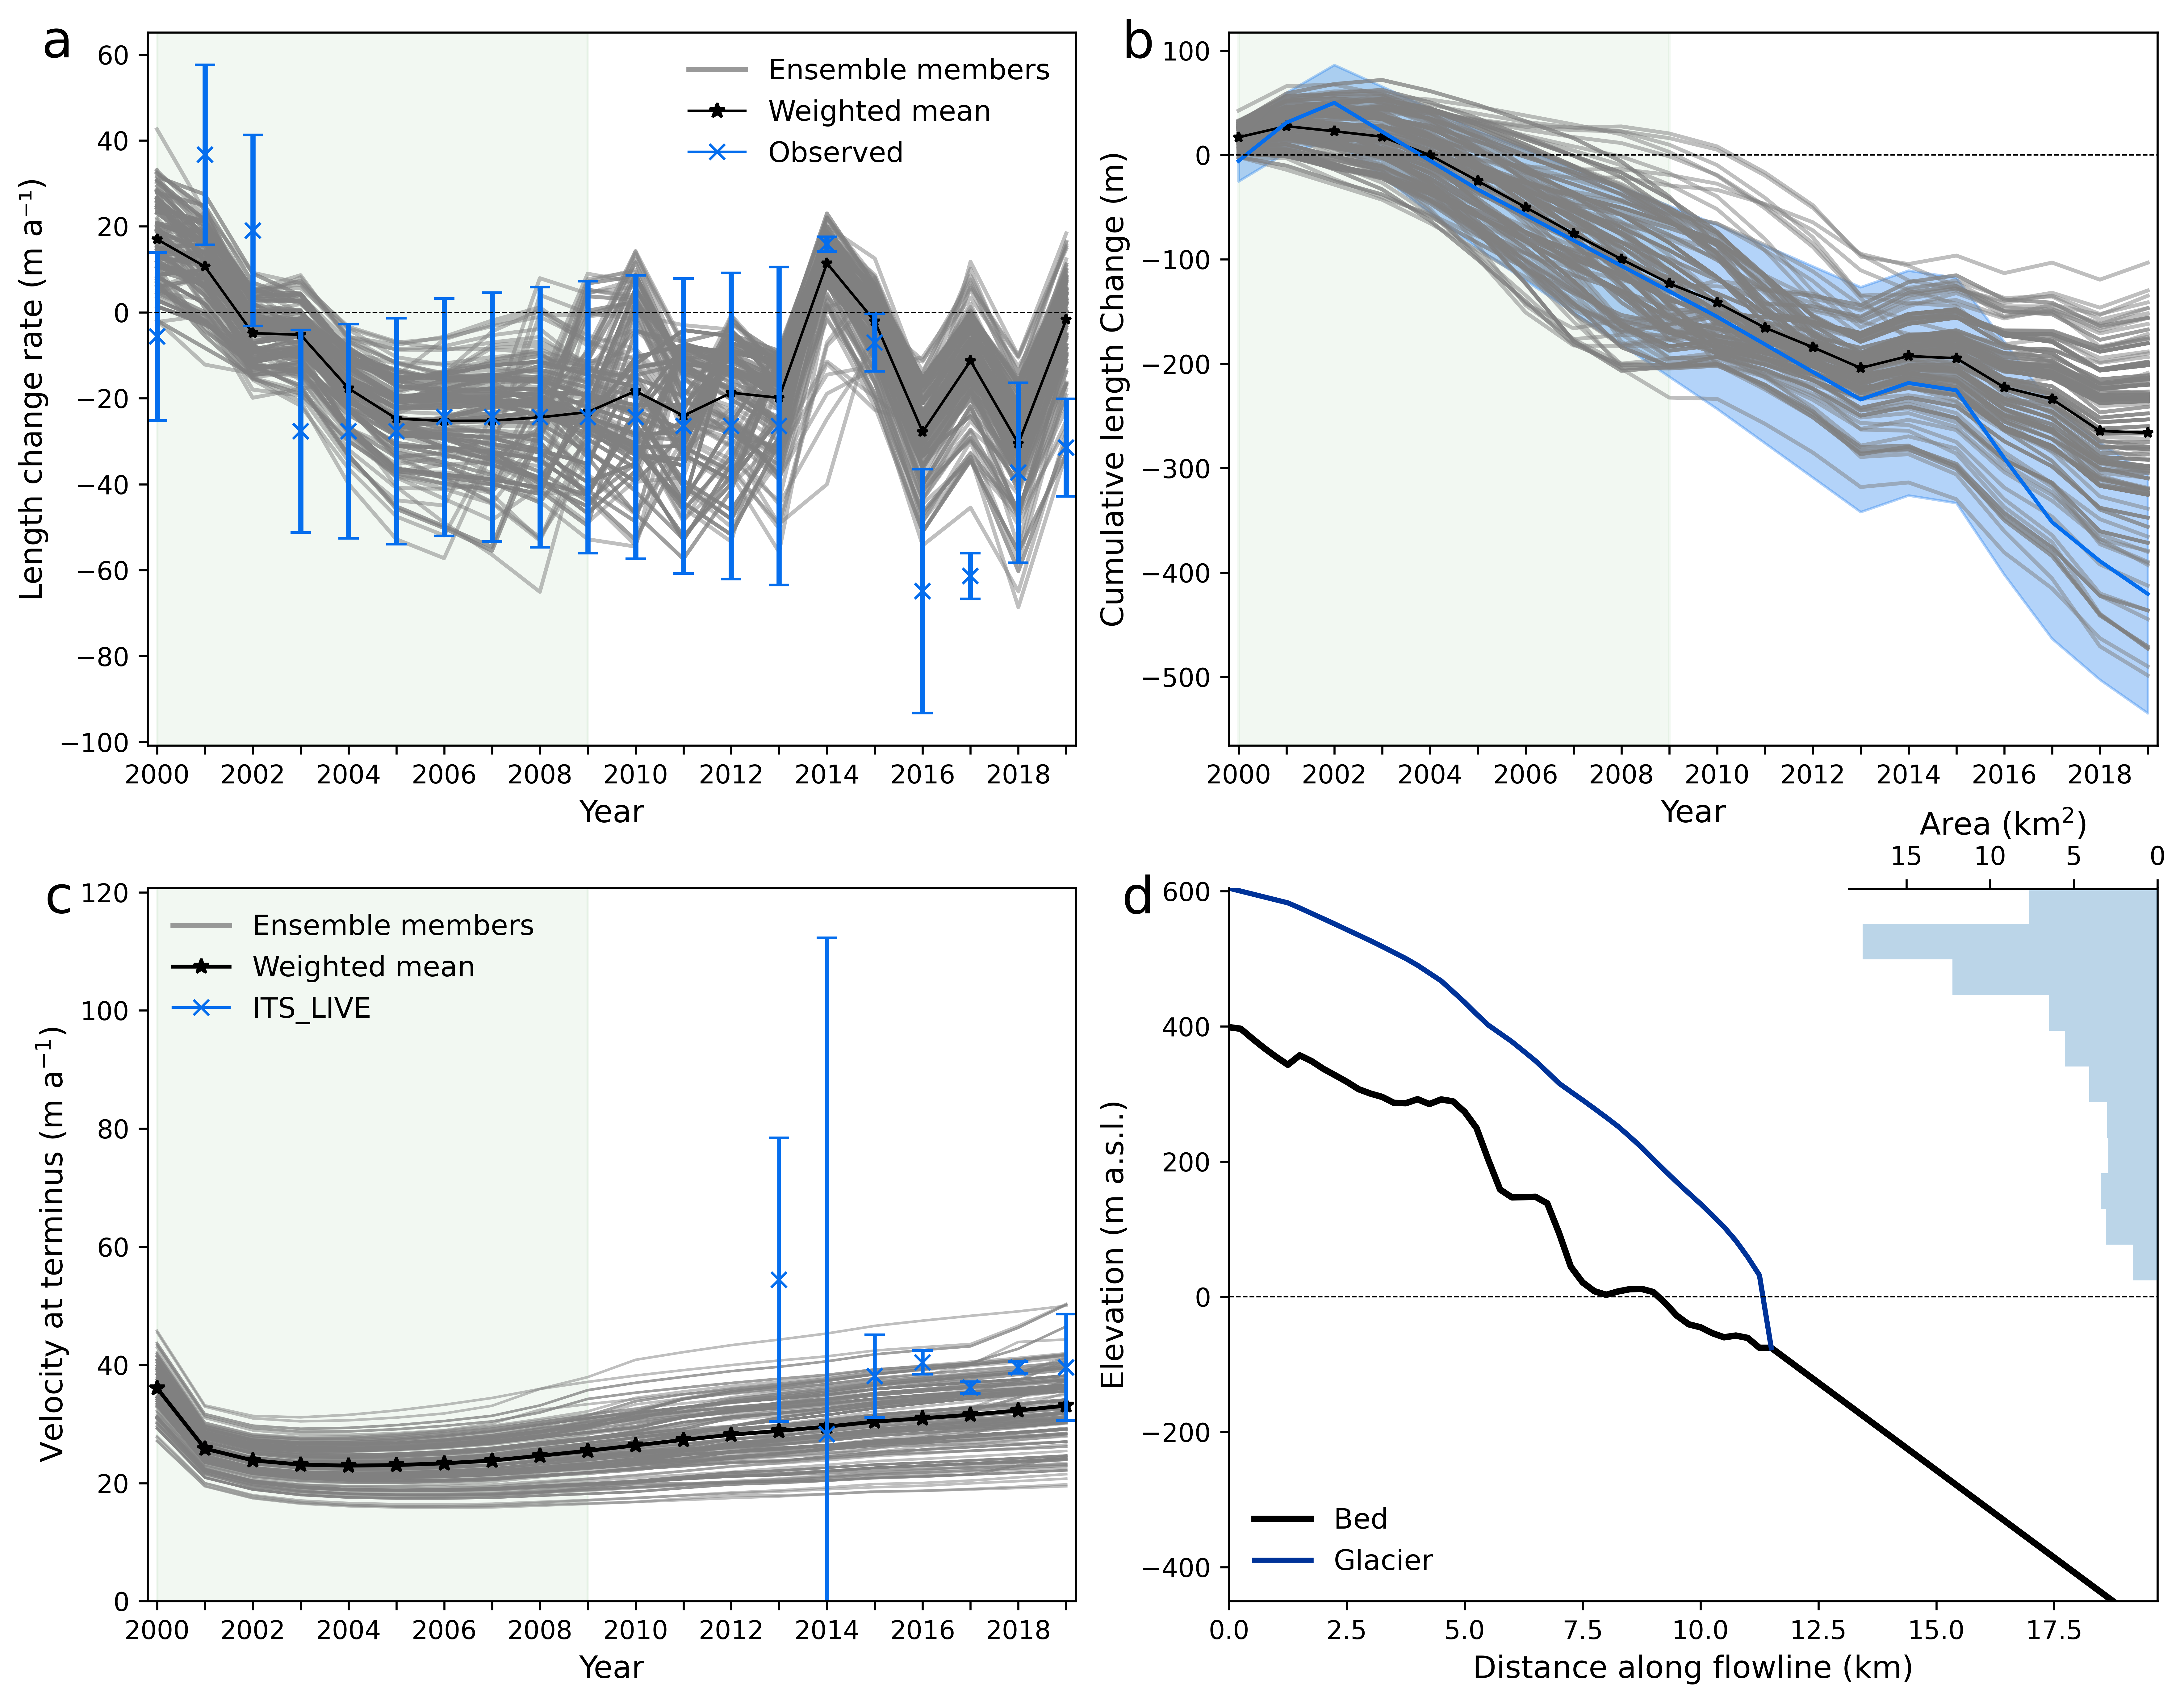

In [13]:
fig, axes = plot_dLdt_topo_Vel_model_vs_obs_2x2(
    output_path=output_path,
    rgiid=RGIID,
    # Additional parameters for velocity and topography
    fls=[bu_fl],
    Vel_model_annual_ensemble=Vel_model_annual_ensemble,
    Vel_model_weighted=Vel_model_weighted,
    Itslive_df=Itslive_df,
    start_year=2000,
    figuresize=(14, 11),
    calibration_period=(2000, 2009),
)

# 6 Plot length change derived from the flowline model profile

In [ ]:

def plot_length_TS_Annual_model_vs_obs_2subplots_Flowline(
    output_path= None,
    output_fn='calibration_model_Annual_output',
    rgiid=None,
    N_iteration='Poster',
    observation_path=None,
    save_path=None,
    save_name=None
):
    """
    Plot cumulative glacier length/dl timeseries from model output and observation data in 4 subplots.

    Parameters:
    - output_path (str): Path to model output data.
    - output_fn (str): File name of the model output data.
    - rgiid (str): Glacier ID.
    - N_iteration (str): Iteration number for model output.
    - observation_path (str): Path to observation data.
    - save_path (str): Path to save the plot.
    - save_name (str): File name to save the plot.
    """

    if not rgiid:
        print("Error: RGI ID must be provided.")
        return

    # Generate regional ID and RGIID float
    reg_id, rgiid_float = extract_regional_rgiid_float(rgiid=rgiid)

    # Load model output
    output_filename = f"modeloutput/{reg_id}/{rgiid_float}/Annual/{output_fn}_{rgiid}_{N_iteration}.json"
    output_fp_annual = os.path.join(output_path, output_filename)

    try:
        with open(output_fp_annual, 'r', encoding='utf-8') as f:
            output_data_annual = json.load(f)
    except Exception as e:
        print(f"Error loading JSON file: {output_fp_annual} - {e}")
        return

    # Load model data
    lengthchange_dLdt_model_array_annual = np.array(output_data_annual['lengthchange_dLdt_model_array_annual_myr'])
    lengthchange_m_TMS_model_array_annual = np.array(output_data_annual['lengthchange_m_TMS_model_array_annual'])

    # Load parameter weights
    output_folder_post_params_unique = os.path.join(output_path, 'parameter', reg_id, rgiid_float, 'Poster', 'Unique')
    output_filename_params_unique_Info = f'calibration_poster_Params_unique_{rgiid}_Info.json'
    output_fp_params_unique_Info = os.path.join(output_folder_post_params_unique, output_filename_params_unique_Info)

    try:
        with open(output_fp_params_unique_Info, 'r') as f:
            parms_UniqInfo_dict = json.load(f)
        unique_counts = parms_UniqInfo_dict['unique_counts']
        weights_unique = unique_counts / np.sum(unique_counts)
    except Exception as e:
        print(f"Error loading parameter info: {e}")
        return

    # Repeat model output based on unique counts and compute weighted averages
    lengthchange_m_TMS_model_array_annual_post = np.repeat(lengthchange_m_TMS_model_array_annual, unique_counts, axis=1)
    
    lengthchange_m_TMS_weighted = np.average(lengthchange_m_TMS_model_array_annual, axis=1, weights=weights_unique)

    # Load observation data
    observation_annual_fn = f'lengthchange_annual_rgi_region01_{int(reg_id)}_20002020.csv'
    observation_annual_fp = os.path.join(observation_path, observation_annual_fn)
    
    try:
        observation_data = pd.read_csv(observation_annual_fp)
        mask = observation_data.RGIId == rgiid
        
        if not mask.any():
            print(f"Error: No observation data found for RGI ID {rgiid}")
            return
            
        obs_annual = np.array(observation_data.loc[mask, 'dLdt_m_per_yr'].apply(ast.literal_eval).tolist(), dtype=float)
        obs_annual_unc = np.array(observation_data.loc[mask, 'dLdt_m_per_yr_unc'].apply(ast.literal_eval).tolist(), dtype=float)
    except Exception as e:
        print(f"Error loading observation data: {e}")
        return

    # Compute cumulative sums
    cum_TMS_model = np.cumsum(lengthchange_m_TMS_model_array_annual_post, axis=0)
    cum_obs = np.cumsum(obs_annual)
    cum_obs_unc = np.sqrt(np.cumsum(obs_annual_unc**2))
    cum_TMS_weighted = np.cumsum(lengthchange_m_TMS_weighted, axis=0)

    # Define years
    X_Years = np.arange(2000, 2000 + cum_TMS_model.shape[0])

    # Create figure and subplots
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), sharex=True)
    
    # Common styling parameters
    ensemble_kwargs = {'color': 'grey', 'alpha': 0.5}
    weighted_kwargs = {'color': 'black', 'marker': '*', 'markersize': 4, 'linewidth': 1, 'alpha': 1}
    obs_error_kwargs = {'fmt': 'x', 'ecolor': '#056eee', 'elinewidth': 1.5, 'capsize': 4, 
                       'mec': '#056eee', 'mfc': '#056eee', 'alpha': 1}
    obs_line_kwargs = {'color': '#056eee',  'marker': 'x', 'markersize': 4,'linewidth': 1.5}
    fill_kwargs = {'color': '#056eee', 'alpha': 0.3}
    calib_kwargs = {'alpha': 0.05, 'color': 'green'}

    # Plot data for each subplot
    plot_configs = [
        # Row 1: Rate of change

        {
            'data': [
                ('ensemble', lengthchange_m_TMS_model_array_annual_post),
                ('weighted', lengthchange_m_TMS_weighted),
                ('obs_error', (obs_annual.squeeze(), obs_annual_unc.squeeze()))
            ],
            'ylabel': "Length change rate (m a⁻¹)",
            'xlabel': "Year",
            'label': ''
        },
        # Row 2: Cumulative change
        {
            'data': [
                ('ensemble', cum_TMS_model),
                ('weighted', cum_TMS_weighted),
                ('obs_line', cum_obs),
                ('fill', (cum_obs - cum_obs_unc, cum_obs + cum_obs_unc))
            ],
            'xlabel': "Year",
            'ylabel': "Cumulative length Change (m)",
            'label': ''
        }
    ]

    # Create plots
    for idx, (ax, config) in enumerate(zip(axes.flat, plot_configs)):
        # Add subplot label (a), (b), (c), (d) at top-left outside
        label_text = f'{chr(97 + idx)}'  # 97 is 'a' in ASCII
        ax.text(-0.07, 1, label_text, transform=ax.transAxes, 
                fontsize=20, fontweight='normal', va='top', ha='right')
        # Calibration period background
        ax.axvspan(2000, 2009, **calib_kwargs)
        
        # Plot data
        for plot_type, data in config['data']:
            if plot_type == 'ensemble':
                ax.plot(X_Years, data, **ensemble_kwargs)
            elif plot_type == 'weighted':
                ax.plot(X_Years, data, **weighted_kwargs)
            elif plot_type == 'obs_error':
                ax.errorbar(X_Years, data[0], yerr=data[1], **obs_error_kwargs)
            elif plot_type == 'obs_line':
                ax.plot(X_Years, data, **obs_line_kwargs)
            elif plot_type == 'fill':
                ax.fill_between(X_Years, data[0], data[1], **fill_kwargs)
        
        # Set labels
        if 'ylabel' in config:
            ax.set_ylabel(config['ylabel'], fontsize=14)
        if 'xlabel' in config: 
            ax.set_xlabel(config['xlabel'], fontsize=14)
        
        # Add model label
        ax.text(0.02, 0.05, config['label'], transform=ax.transAxes, fontsize=12, color='black')
        
        # Set x-ticks
        ax.set_xticks(X_Years)
        ax.set_xticklabels([str(year) if year % 2 == 0 else "" for year in X_Years])

        # add the y=0 horizontal line
        ax.axhline(y=0,linestyle='--',color='k',linewidth=0.5)

    # Add legend to first subplot
    legend_handles = [
        mlines.Line2D([], [], color='grey', alpha=0.8, linewidth=1, label='Modeled ensemble'),
        mlines.Line2D([], [], color='black', marker='*', markersize=4,linewidth=1, label='Weighted mean'),
        mlines.Line2D([], [], color='#056eee', marker='x', markersize=4, linewidth=1, label='Observed')
        
    ]
    axes[0].legend(handles=legend_handles, loc='best', fontsize=12,frameon=False)

    plt.tight_layout()

    # Save figure
    if save_path is None:
        save_path = os.path.join(output_path, 'figures', reg_id, rgiid_float)
    
    if save_name is None:
        save_name = f'Glacier_lengthchange_timeseries_model_vs_obs_{rgiid}_flowline'
    
    os.makedirs(save_path, exist_ok=True)
    save_file = os.path.join(save_path, save_name + '_2subplots.png')
    plt.savefig(save_file, bbox_inches='tight', dpi=300)
    print(f"Figure saved to {save_file}")
    
    return fig, axes,lengthchange_m_TMS_model_array_annual,lengthchange_dLdt_model_array_annual

Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/figures/07/7.00036/Glacier_lengthchange_timeseries_model_vs_obs_RGI60-07.00036_flowline_2subplots.png


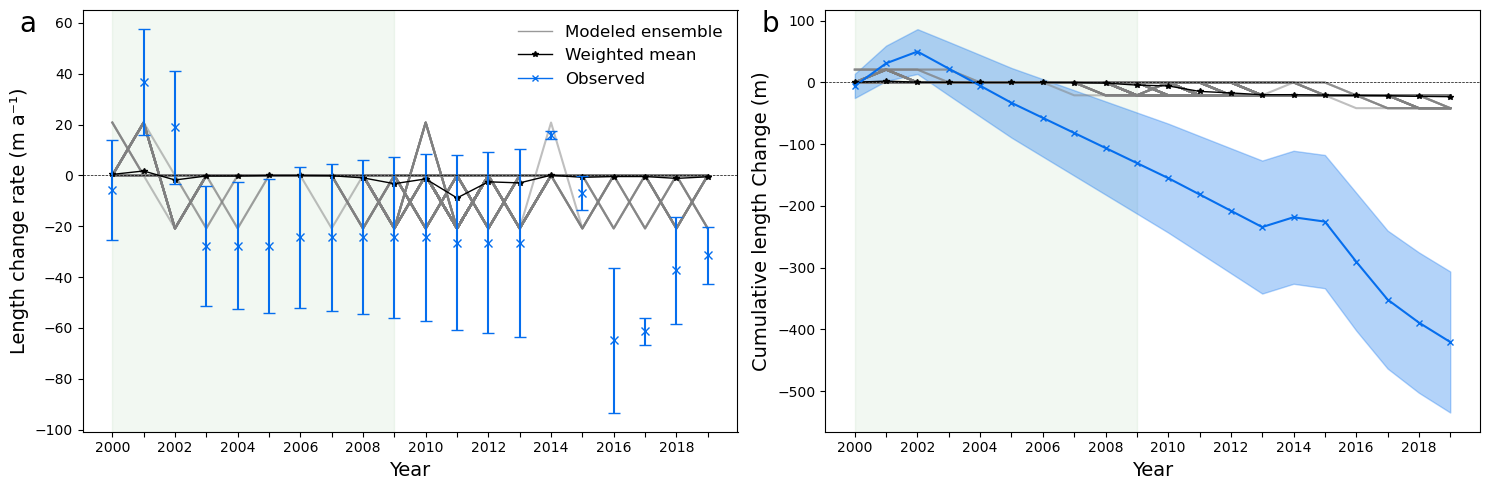

In [ ]:
fig,axes,lengthchange_m_TMS_model_array_annual,lengthchange_dLdt_model_array_annual=plot_length_TS_Annual_model_vs_obs_2subplots_Flowline(output_path= output_path,
                           output_fn='calibration_model_Annual_output',rgiid = 'RGI60-07.00036', N_iteration = 'Poster',
                           observation_path= observation_path, 
                           save_path=None, save_name=None)

# 7. Seasonal variability

In [14]:
# Read the model dLdt ensemble and weighted average
output_fn = 'calibration_model_Monthly_output'
N_iteration = 'Poster'
rgiid=RGIID
reg_id, rgiid_float = extract_regional_rgiid_float(rgiid=RGIID)

In [15]:
# Load model output from JSON file
output_filename = f"modeloutput/{reg_id}/{rgiid_float}/Monthly/{output_fn}_{rgiid}_{N_iteration}.json" 
output_fp_monthly = os.path.join(output_path, output_filename)

try:
    with open(output_fp_monthly, 'r', encoding='utf-8') as f:
        output_data_monthly = json.load(f)
except:
    print(f"Error loading JSON file: {output_fp_monthly}")
    output_data_monthly = None  # or an empty dict {} if needed

# Load model length change data
lengthchange_dLdt_model_array_monthly = np.array(output_data_monthly['lengthchange_dLdt_model_array_monthly'])
lengthchange_m_TMS_model_array_monthly = np.array(output_data_monthly['lengthchange_m_TMS_model_array_monthly'])
# Load model Frontal ablation
FA_model_array_monthly = np.array(output_data_monthly['calving_flux_Gta_TMS_model_array_monthly'])
MB_total_model_array_monthly = np.array(output_data_monthly['massbaltotal_TMS_model_array_monthly'])
MB_climatic_model_array_monthly = np.array(output_data_monthly['massbalclim_TMS_model_array_monthly'])

# ==== restruct based on the weights (read the Unique info of Model posterior parameters)
# load the unique weightes, counts
output_folder_post_params_unique =  os.path.join(output_path, 'parameter', reg_id, rgiid_float, 'Poster', 'Unique')
output_filename_params_unique_Info = f'calibration_poster_Params_unique_{rgiid}_Info.json'
output_fp_params_unique_Info = os.path.join(output_folder_post_params_unique, output_filename_params_unique_Info) 

with open(output_fp_params_unique_Info, 'r') as f:
    parms_UniqInfo_dict = json.load(f)
unique_counts= parms_UniqInfo_dict['unique_counts']

# repeat the model output based on the unique counts

lengthchange_dLdt_model_array_monthly_post = np.repeat(lengthchange_dLdt_model_array_monthly,unique_counts,axis = 0)
lengthchange_m_TMS_model_array_monthly_post = np.repeat(lengthchange_m_TMS_model_array_monthly,unique_counts,axis = 0)
FA_model_array_monthly_post = np.repeat(FA_model_array_monthly,unique_counts,axis = 0)
MB_total_model_array_monthly_post = np.repeat(MB_total_model_array_monthly,unique_counts,axis = 0)
MB_climatic_model_array_monthly_post = np.repeat(MB_climatic_model_array_monthly,unique_counts,axis = 0)
# generate the weighted average
Weights_unique = unique_counts/np.sum(unique_counts)

lengthchange_dLdt_model_array_monthly_weighted = np.average(lengthchange_dLdt_model_array_monthly,axis = 0,weights = Weights_unique)
lengthchange_m_TMS_model_array_monthly_weighted = np.average(lengthchange_m_TMS_model_array_monthly,axis = 0,weights = Weights_unique)
FA_model_array_monthly_weighted = np.average(FA_model_array_monthly,axis =0,weights = Weights_unique)
MB_total_model_array_monthly_weighted = np.average(MB_total_model_array_monthly,axis = 0,weights = Weights_unique)
MB_climatic_model_array_monthly_weighted = np.average(MB_climatic_model_array_monthly,axis = 0,weights = Weights_unique)





In [ ]:
def plot_monthly_dLdt_and_FA (output_path= None,
    output_fn='calibration_model_Monthly_output',
    rgiid=None,
    N_iteration='Poster',
    calib_simul_period = ('2000-01', '2010-01', '2020-01'),
    save_path=None,
    save_name=None,
    fig_fontsize=12,
    fig_figsize=(15, 5),
    fig_dpi=300,):
    """
    Plot monthly variation of modeled length change rate and Frontal ablation.
    Parameters:
    - output_path (str): Path to model output data.
    - output_fn (str): File name of the model output data.
    - rgiid (str): Glacier ID.
    - N_iteration (str): Iteration number for model output.
    - calib_simul_period (tuple): (start, calib_end, simu_end) months for calibration period shading, and the simulation period.
    - save_path (str): Path to save the figure.
    - save_name (str): Name of the saved figure file.
    - fig_fontsize (int): Font size for labels and titles.
    - figuresize (tuple): Figure size (width, height) in inches.
    - fig_dpi (int): Resolution of the saved figure.
    Returns:
    - None
    """
    if not rgiid:
        print("Error: RGI ID must be provided.")
        return
    # Generate regional ID and RGIID float
    reg_id, rgiid_float = extract_regional_rgiid_float(rgiid=rgiid)
    # Load model output for monthly data
    output_filename = f"modeloutput/{reg_id}/{rgiid_float}/Monthly/{output_fn}_{rgiid}_{N_iteration}.json" 
    output_fp_monthly = os.path.join(output_path, output_filename)

    try:
        with open(output_fp_monthly, 'r', encoding='utf-8') as f:
            output_data_monthly = json.load(f)
    except:
        print(f"Error loading JSON file: {output_fp_monthly}")
        output_data_monthly = None  # or an empty dict {} if needed
    
    # Load model length change data
    lengthchange_dLdt_model_array_monthly = np.array(output_data_monthly['lengthchange_dLdt_model_array_monthly'])
    # Load model Frontal ablation
    FA_model_array_monthly = np.array(output_data_monthly['calving_flux_Gta_TMS_model_array_monthly'])

    # ==== restruct based on the weights (read the Unique info of Model posterior parameters)
    # load the unique weightes, counts
    output_folder_post_params_unique =  os.path.join(output_path, 'parameter', reg_id, rgiid_float, 'Poster', 'Unique')
    output_filename_params_unique_Info = f'calibration_poster_Params_unique_{rgiid}_Info.json'
    output_fp_params_unique_Info = os.path.join(output_folder_post_params_unique, output_filename_params_unique_Info) 

    with open(output_fp_params_unique_Info, 'r') as f:
        parms_UniqInfo_dict = json.load(f)
    unique_counts= parms_UniqInfo_dict['unique_counts']

    # repeat the model output based on the unique counts

    lengthchange_dLdt_model_array_monthly_post = np.repeat(lengthchange_dLdt_model_array_monthly,unique_counts,axis = 0)

    FA_model_array_monthly_post = np.repeat(FA_model_array_monthly,unique_counts,axis = 0)

    # generate the weighted average
    Weights_unique = unique_counts/np.sum(unique_counts)

    lengthchange_dLdt_model_array_monthly_weighted = np.average(lengthchange_dLdt_model_array_monthly,axis = 0,weights = Weights_unique)
    FA_model_array_monthly_weighted = np.average(FA_model_array_monthly,axis =0,weights = Weights_unique)
    # Define time axis
    dates = pd.date_range(calib_simul_period[0], calib_simul_period[2], freq='ME')
    n_months = len(dates)

    # === Create figure and axes
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=fig_figsize, dpi=fig_dpi)
    # Add calibration period shading
    for ax in axes:
        # Add calibration period background
        ax.axvspan(pd.to_datetime(calib_simul_period[0]), pd.to_datetime(calib_simul_period[1]), alpha=0.05, color='green')
    # First subplot: Monthly Length Change Rate
    # Plot dLdt
    axes[0].axhline(y=0,linestyle='--',color ='k',linewidth = 0.5)
    axes[0].plot(dates, lengthchange_dLdt_model_array_monthly_post.T, color='grey', alpha=0.4, linewidth=0.5)
    axes[0].plot(dates, lengthchange_dLdt_model_array_monthly_weighted, color='black', marker='*', markersize=2, linewidth=1.5, alpha=0.8)
    axes[0].set_ylabel('Length change rate (m a$^{-1}$)', fontsize=fig_fontsize)

    # Plot FA
    axes[1].plot(dates, FA_model_array_monthly_post.T, color='grey', alpha=0.4, linewidth=0.5)
    axes[1].plot(dates, FA_model_array_monthly_weighted, color='black', marker='*', markersize=2, linewidth=1.5, alpha=0.8)
    axes[1].set_ylabel('Frontal ablation (Gt a$^{-1}$)', fontsize=fig_fontsize)
    # Add legend to first length change subplot
    len_legend_handles = [
        mlines.Line2D([], [], color='grey', alpha=0.5, linewidth=1, label='Ensemble members'),
        mlines.Line2D([], [], color='black', marker='*', markersize=6, linewidth=2, label='Weighted mean'),
    ]
    axes[1].legend(handles=len_legend_handles, loc='upper left', fontsize=fig_fontsize-1, frameon=False)
    # X-axis settings for both plots
    for ax in axes:
        # Set x-axis ticks for January and July of each year
        major_ticks = dates[(dates.month == 7)]  # Get every January and July ¦(dates.month == 1)
        ax.set_xticks(major_ticks)  # Set ticks at major_ticks

        # Create labels for ticks
        tick_labels = []
        for date in major_ticks:
            month_str = date.strftime('%b')  # Get month abbreviation (e.g., Jan, Jul)
            year_str = date.strftime('%Y')    # Get year
            if date.year % 2 == 0:  # Only label every 2 years
                tick_labels.append(f"{month_str}\n{year_str}")  # Format to two lines
            else:
                tick_labels.append("")  # Empty label for non-even years

        ax.set_xticklabels(tick_labels, rotation=0, ha='center')  # Set tick labels

        # Adding dashed vertical lines after each year
        years = pd.date_range(start=dates.min(), end=dates.max(), freq='YE')  # Year start frequency
        for year in years:
            ax.axvline(x=year, linestyle='--', color='gray', linewidth=0.5)  # Add a dashed vertical line

        # Set x-axis limits based on the min and max of the date_range
        ax.set_xlim(dates.min(), dates.max())
        ax.set_xlabel('Date', fontsize= fig_fontsize)

    # Add subplot labels
    for i, ax in enumerate(axes):
        label = chr(97 + i)  # a, b, c, d, e, f
        ax.text(-0.08, 0.95, label, transform=ax.transAxes, 
                fontsize=20, fontweight='normal', va='bottom', ha='right')
    # Save figure
    if save_path is None:
        save_path = os.path.join(output_path, 'figures', reg_id, rgiid_float)
        os.makedirs(save_path, exist_ok=True)
    if save_name is None:
        save_name = f'Glacier_monthly_dLdt_and_FA_model_{rgiid}_Updated.png'
    
    save_file = os.path.join(save_path, save_name)
    plt.savefig(save_file,bbox_inches='tight', dpi=300)
    print(f"Monthly dLdt and FA figure saved to: {save_file}")
    plt.show()
    plt.close()


Monthly dLdt and FA figure saved to: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/figures/07/7.00036/Glacier_monthly_dLdt_and_FA_model_RGI60-07.00036_Updated.png


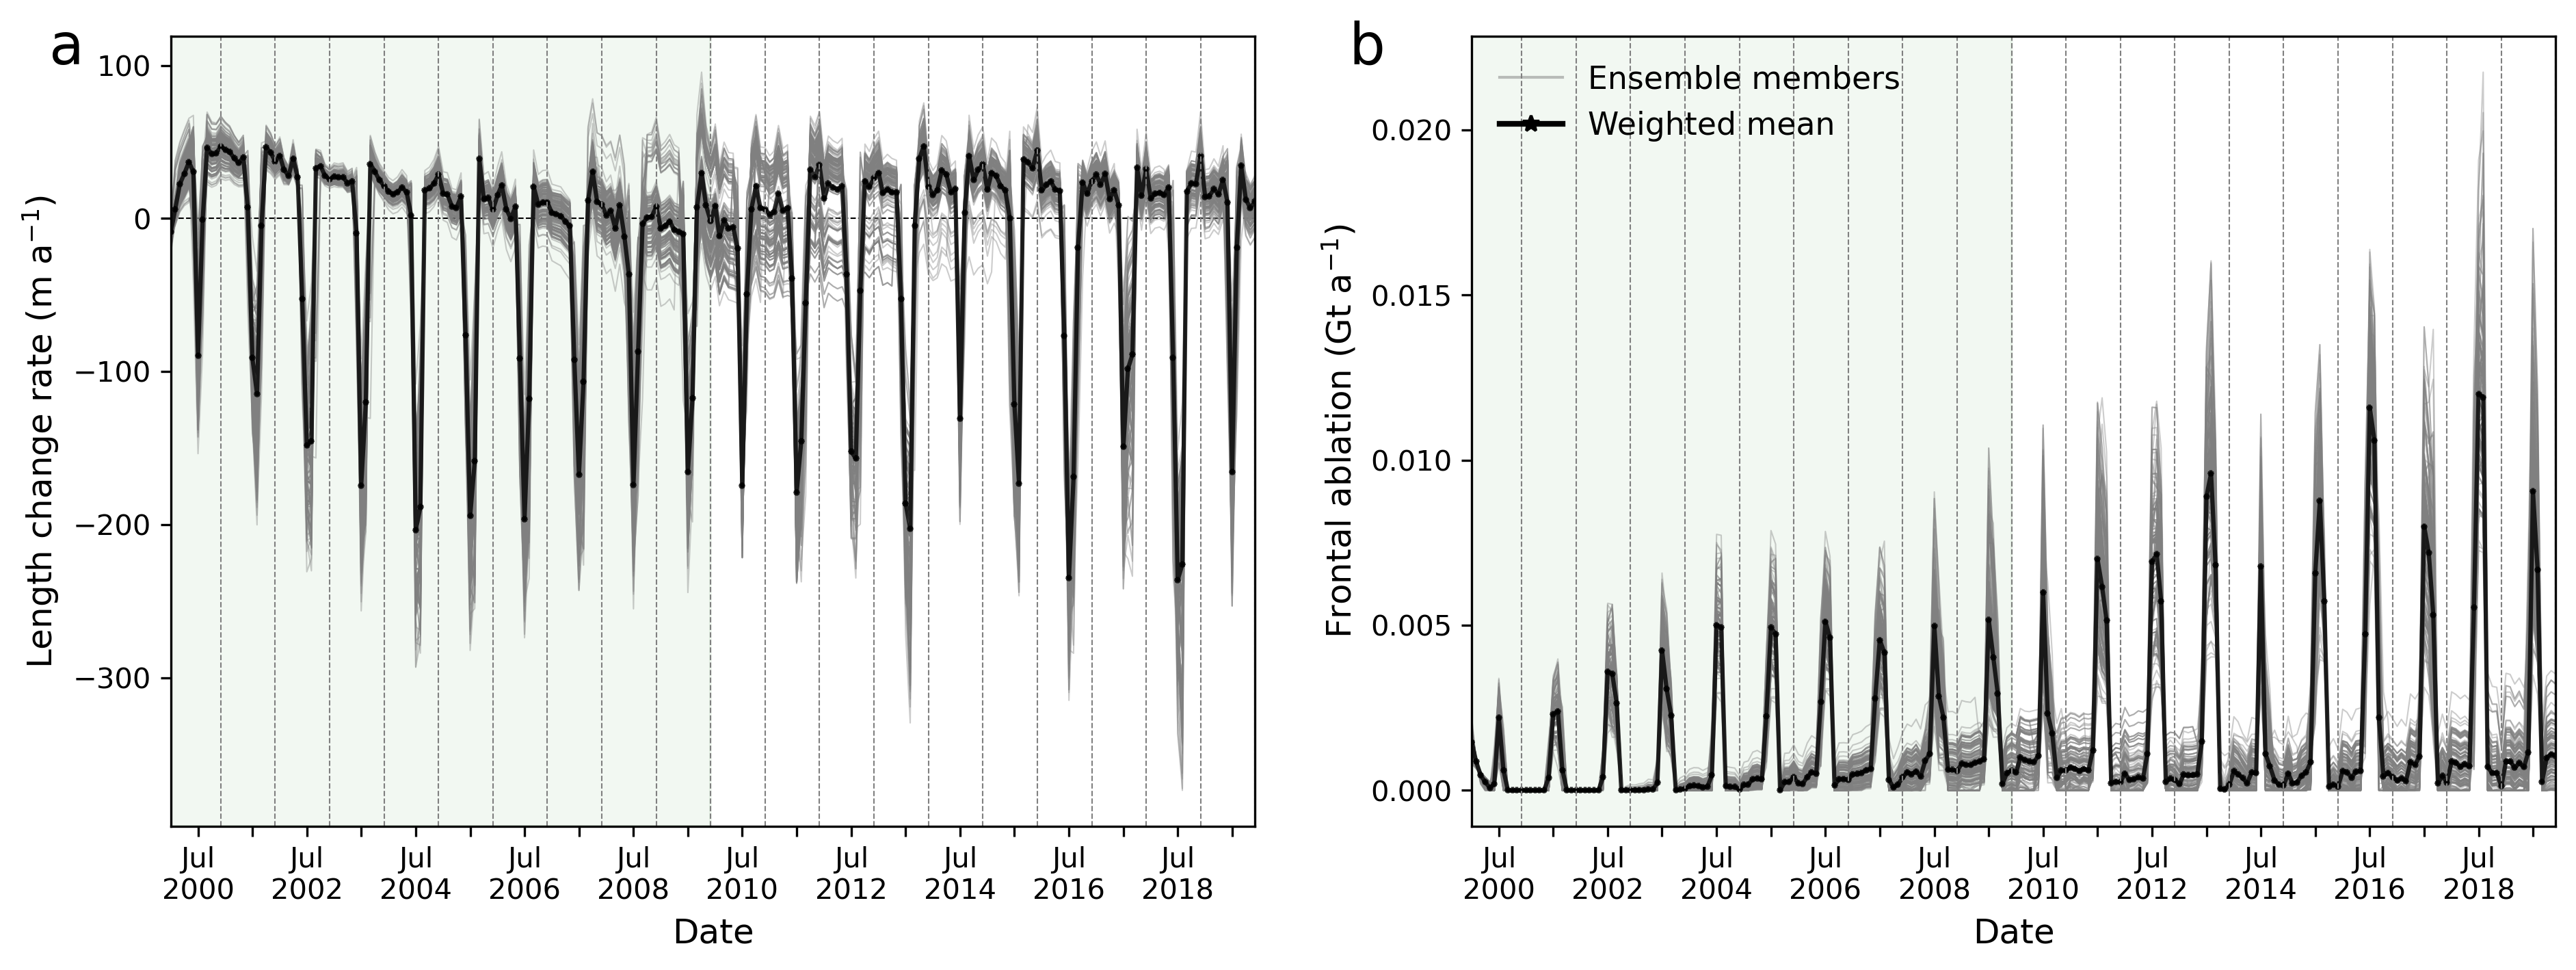

In [ ]:
plot_monthly_dLdt_and_FA (output_path= output_path,
    output_fn='calibration_model_Monthly_output',rgiid=RGIID,)